In [1]:
import os
import sys
import json
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, SequentialSampler, TensorDataset
from tqdm import tqdm
from safetensors.torch import load_file
from transformers import AutoTokenizer
from collections import Counter
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

from src.ocula.models.classifier import OculaClassifier
from src.ocula.data.preprocess import TextCleaner

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PLOT_DIR = "../notebooks/plots/error_analysis/"
os.makedirs(PLOT_DIR, exist_ok=True)

TEST_PATH = "../data/splits/test.csv"
RESULTS_PATH = "../checkpoints/muril_base/results.json"
CKPT_PATH = "../checkpoints/muril_base/checkpoint-25870/model.safetensors"
MODEL_NAME = "google/muril-base-cased"

CLASS_LABELS_MAP = {0: "Hate", 1: "Offensive", 2: "Normal"}

matplotlib.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.prop_cycle": matplotlib.cycler(color=["#111111","#555555","#999999","#CCCCCC"]),
    "hatch.linewidth": 0.6,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

d:\Codes\ocula\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
# Load dataset
df_test = pd.read_csv(TEST_PATH)
print(f"Loaded test set with {len(df_test)} rows.")

# Initialize model components
cleaner = TextCleaner(lowercase=True)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = OculaClassifier(model_name=MODEL_NAME)

state_dict = load_file(CKPT_PATH)
model.load_state_dict(state_dict)
model.eval().to(device)

cleaned_texts = [cleaner.clean(str(text)) for text in df_test["text"].tolist()]

encodings = tokenizer(
    cleaned_texts,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

dataset = TensorDataset(encodings["input_ids"], encodings["attention_mask"])
dataloader = DataLoader(dataset, sampler=SequentialSampler(dataset), batch_size=32)

pred_labels = []
confidence_scores = []

with torch.no_grad():
    for batch in tqdm(dataloader, desc="Running MuRIL Inference"):
        input_ids, attention_mask = batch[0].to(device), batch[1].to(device)
        
        encoder_out = model.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooler_output = encoder_out[1] if hasattr(encoder_out, 'pooler_output') and encoder_out[1] is not None else encoder_out[0][:, 0]
        
        dropped_out = model.dropout(pooler_output)
        logits = model.classifier(dropped_out)
        
        probs = F.softmax(logits, dim=-1)
        conf, preds = torch.max(probs, dim=-1)
        
        pred_labels.extend(preds.cpu().numpy())
        confidence_scores.extend(conf.cpu().numpy())

# Populate metadata attributes back into main DataFrame
df_test["pred_label"] = pred_labels
df_test["true_label"] = df_test["label_int"]
df_test["confidence"] = confidence_scores
df_test["correct"] = df_test["pred_label"] == df_test["true_label"]

# Generate structural text-length column if not present
if "word_count" not in df_test.columns:
    df_test["word_count"] = df_test["text"].apply(lambda x: len(str(x).split()))

Loaded test set with 10346 rows.


Running MuRIL Inference: 100%|██████████| 324/324 [01:52<00:00,  2.88it/s]


                      OVERALL ERROR METRICS PROFILE                    
Total Test Set Records  : 10346
Total Incorrect Missteps: 1643
Overall Error Rate      : 15.88%
-----------------------------------------------------------------------
           Total Count  Accuracy  Error Rate
Class                                       
Hate              1176  0.742347    0.257653
Offensive         3666  0.837152    0.162848
Normal            5504  0.865007    0.134993


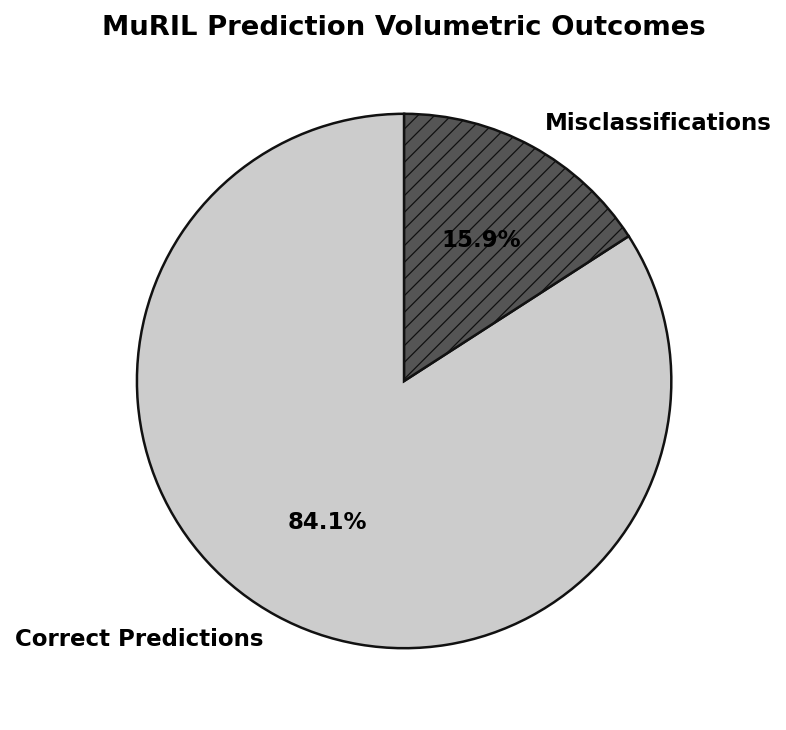

In [3]:
correct_counts = df_test["correct"].value_counts()
total_samples = len(df_test)
total_errors = correct_counts.get(False, 0)
overall_error_rate = total_errors / total_samples

# Calculate accuracy boundaries per class category
summary_metrics = []
for idx, c_name in CLASS_LABELS_MAP.items():
    class_df = df_test[df_test["true_label"] == idx]
    c_total = len(class_df)
    c_correct = class_df["correct"].sum()
    c_acc = c_correct / c_total if c_total > 0 else 0
    
    summary_metrics.append({
        "Class": c_name,
        "Total Count": c_total,
        "Accuracy": c_acc,
        "Error Rate": 1.0 - c_acc
    })

df_error_summary = pd.DataFrame(summary_metrics).set_index("Class")

print("=======================================================================")
print("                      OVERALL ERROR METRICS PROFILE                    ")
print("=======================================================================")
print(f"Total Test Set Records  : {total_samples}")
print(f"Total Incorrect Missteps: {total_errors}")
print(f"Overall Error Rate      : {overall_error_rate*100:.2f}%")
print("-----------------------------------------------------------------------")
print(df_error_summary.to_string())
print("=======================================================================")

# Plot: Classification Breakdown Pie Chart
plt.figure(figsize=(12, 5))
plt.pie([total_samples - total_errors, total_errors], 
        labels=["Correct Predictions", "Misclassifications"], 
        colors=["#CCCCCC", "#555555"], 
        hatch=["", "///"],
        autopct="%1.1f%%", startangle=90, 
        textprops={"fontweight": "bold"},
        wedgeprops={"edgecolor": "#111111", "linewidth": 1.2})
plt.title("MuRIL Prediction Volumetric Outcomes", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}overall_error_pie.png")
plt.show()

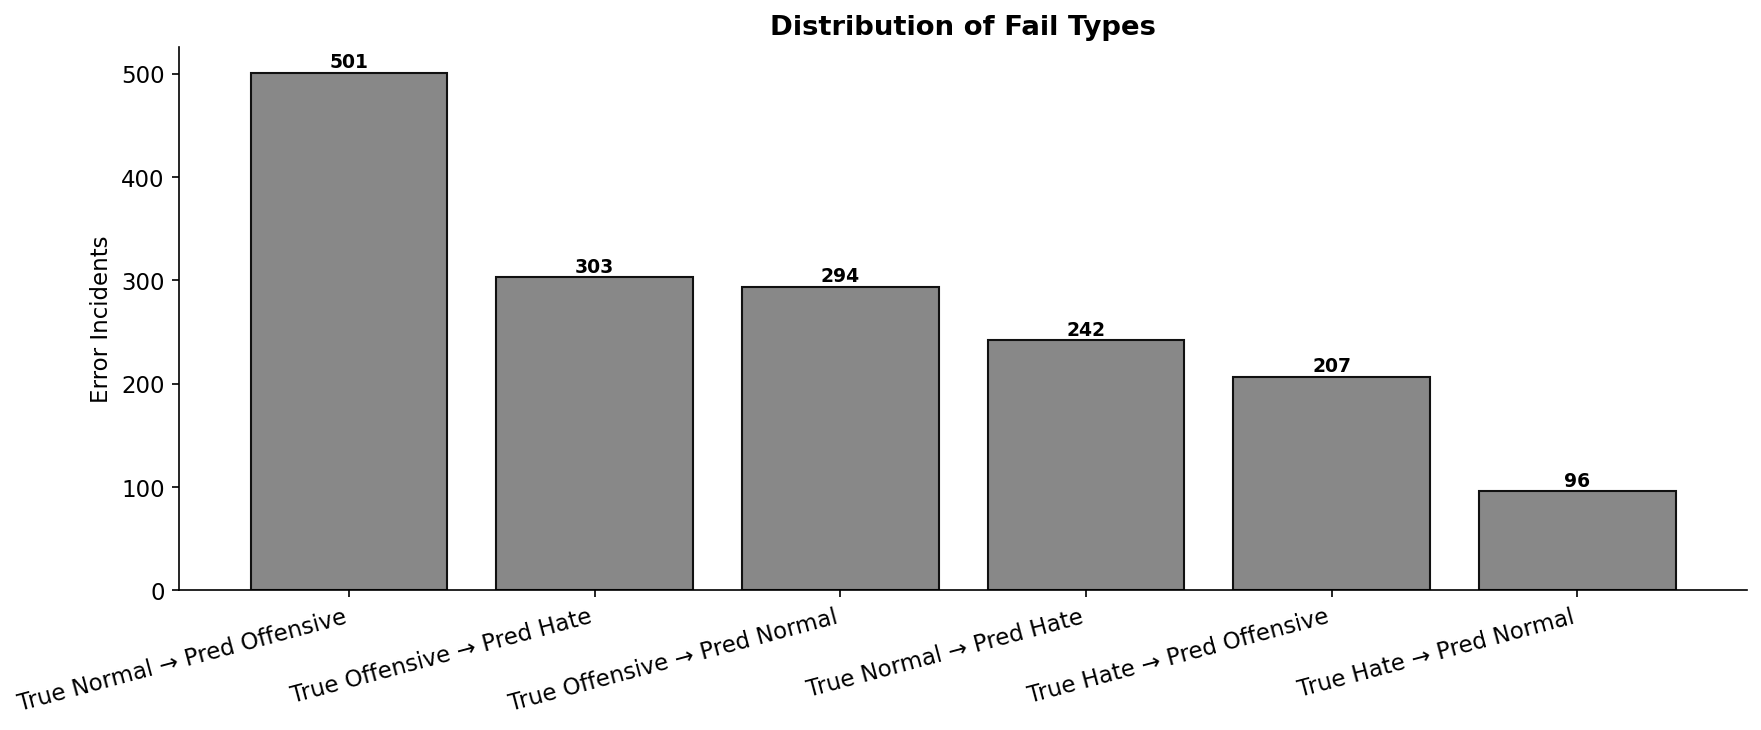

In [5]:
error_df = df_test[~df_test["correct"]]
confusion_pairs = []

# Map out distinct types of confusion options
for true_idx, true_name in CLASS_LABELS_MAP.items():
    for pred_idx, pred_name in CLASS_LABELS_MAP.items():
        if true_idx == pred_idx:
            continue
        count = len(error_df[(error_df["true_label"] == true_idx) & (error_df["pred_label"] == pred_idx)])
        confusion_pairs.append({
            "Pair": f"True {true_name} → Pred {pred_name}",
            "Count": count
        })

df_confusion_bars = pd.DataFrame(confusion_pairs).sort_values(by="Count", ascending=False)

plt.figure(figsize=(12, 5))
bars = plt.bar(df_confusion_bars["Pair"], df_confusion_bars["Count"], edgecolor="#111111", color="#888888")

# Structural annotation loop
for bar in bars:
    h = bar.get_width()
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(df_confusion_bars["Count"])*0.01),
             f"{int(bar.get_height())}", ha="center", fontweight="bold", fontsize=9)

plt.title("Distribution of Fail Types", fontweight="bold")
plt.ylabel("Error Incidents")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}confusion_breakdown_bars.png")
plt.show()

In [6]:
# False Positives: Ground truth is Normal, model tagged as Hate/Offensive
fp_df = df_test[(df_test["true_label"] == 2) & (df_test["pred_label"].isin([0, 1]))]
fp_top10 = fp_df.sort_values(by="confidence", ascending=False).head(10)

print("==========================================================================================")
print("                   TOP 10 CRITICAL FALSE POSITIVE MISCLASSIFICATIONS                       ")
print("==========================================================================================")
pd.set_option('display.max_colwidth', 120)
print(fp_top10[["text", "pred_label", "confidence"]].to_string(
    formatters={"text": lambda x: f"{str(x)[:117]}...", "pred_label": lambda x: CLASS_LABELS_MAP[x]}
))
print("==========================================================================================")

                   TOP 10 CRITICAL FALSE POSITIVE MISCLASSIFICATIONS                       
                                                                                                                          text pred_label  confidence
6492                                       when a fic has " smell of " in its title and you just know … those a b o bitches...  Offensive    0.915275
7342                                           rt [user]: todays horoscope: you're still a hoe that is all. have a nice day...  Offensive    0.912775
2073                                                                   brave lady ye kayar indian flag par khade hai gaddar...  Offensive    0.905294
3987                                                                                tu jarasa aaighala ahe ka[enraged_face]...  Offensive    0.904272
10                                                                                     bhen de lodya kite sade age na aaji....  Offensive    0.899549
897     

In [7]:
# False Negatives: Ground truth is Hate, model tagged as Normal/Offensive
fn_df = df_test[(df_test["true_label"] == 0) & (df_test["pred_label"].isin([1, 2]))]
fn_top10 = fn_df.sort_values(by="confidence", ascending=False).head(10)

print("==========================================================================================")
print("                   TOP 10 CRITICAL FALSE NEGATIVE MISCLASSIFICATIONS                       ")
print("==========================================================================================")
print(fn_top10[["text", "pred_label", "confidence"]].to_string(
    formatters={"text": lambda x: f"{str(x)[:117]}...", "pred_label": lambda x: CLASS_LABELS_MAP[x]}
))
print("==========================================================================================")

                   TOP 10 CRITICAL FALSE NEGATIVE MISCLASSIFICATIONS                       
                                                                                                                          text pred_label  confidence
4999                                                                             codo codo [clapping_hands][clapping_hands]...     Normal    0.923507
8195          jab sabhi post par brahman or thakur ban jata hai, usi ko ram rajya kahte hai, baki tamasa to dekh hi rahe ho...     Normal    0.922466
1023  rt [user]: [user] [user] true i need to sleep to make them gainz bruh!! so all the hoes stay mirin ;p alright, later…...  Offensive    0.911964
8880               it's so shady when you bitches talk to guys w/ girlfriends that's so disrespectful to do to another girl...  Offensive    0.911243
1698  "in gurugram muslim man told to remove skullcap,chant jai shri ram". it is deplorable. exemplary action needed by gur...     Normal    0.906432
7372    

In [8]:
# Isolate entries caught in cross-category transitions between Hate (0) and Offensive (1)
confused_ho_df = df_test[
    ((df_test["true_label"] == 0) & (df_test["pred_label"] == 1)) |
    ((df_test["true_label"] == 1) & (df_test["pred_label"] == 0))
]

# Vocabulary evaluation step
all_tokens = []
for txt in confused_ho_df["text"].dropna().tolist():
    tokens = cleaner.clean(str(txt)).split()
    # Filter non-informative functional components
    all_tokens.extend([t for t in tokens if len(t) > 3])

common_error_vocabulary = Counter(all_tokens).most_common(15)

print("=======================================================================")
print("             TOP 15 OVERLAPPING TOKENS INSIDE THE HO CRISIS ZONE       ")
print("=======================================================================")
for idx, (tok, count) in enumerate(common_error_vocabulary):
    print(f"  {idx+1:<3} Token Reference: '{tok:<20}' | Occurrences: {count}")
print("=======================================================================\n")

# Extract specific examples for targeted direction analysis
h_to_o = df_test[(df_test["true_label"] == 0) & (df_test["pred_label"] == 1)].head(5)
o_to_h = df_test[(df_test["true_label"] == 1) & (df_test["pred_label"] == 0)].head(5)

print("Directional Swap Examples (True Hate → Pred Offensive):")
for idx, r in h_to_o.iterrows():
    print(f"  - [{r['confidence']:.3f}]: {str(r['text'])[:110]}...")
    
print("\nDirectional Swap Examples (True Offensive → Pred Hate):")
for idx, r in o_to_h.iterrows():
    print(f"  - [{r['confidence']:.3f}]: {str(r['text'])[:110]}...")

             TOP 15 OVERLAPPING TOKENS INSIDE THE HO CRISIS ZONE       
  1   Token Reference: '[user]              ' | Occurrences: 170
  2   Token Reference: 'that                ' | Occurrences: 99
  3   Token Reference: 'with                ' | Occurrences: 56
  4   Token Reference: 'white               ' | Occurrences: 50
  5   Token Reference: 'this                ' | Occurrences: 49
  6   Token Reference: '[user]:             ' | Occurrences: 45
  7   Token Reference: 'like                ' | Occurrences: 45
  8   Token Reference: 'have                ' | Occurrences: 43
  9   Token Reference: 'they                ' | Occurrences: 40
  10  Token Reference: '<user>              ' | Occurrences: 38
  11  Token Reference: 'bitch               ' | Occurrences: 36
  12  Token Reference: 'what                ' | Occurrences: 35
  13  Token Reference: 'your                ' | Occurrences: 35
  14  Token Reference: 'jews                ' | Occurrences: 33
  15  Token Reference: 'people 